# Dataset 1: NSL-KDD Exploration

**Goal:** As a machine learning student, your first task is to understand the data you are working with. 
Before we can train an AI to detect cyber attacks, we need to load the raw data, see what it looks like, and understand the balance between normal traffic and malicious attacks.

### Step 0: Import Required Libraries
We only need two standard libraries for this:
- `pandas` for reading and manipulating the data.
- `matplotlib` for drawing graphs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Make our graphs look a bit nicer
plt.style.use('ggplot')

### Step 1: Define the Columns
The raw NSL-KDD dataset (`KDDTrain+.txt`) does not have a header row. If we load it directly, Pandas won't know the names of the features. 
We must manually provide the 43 official column names below.

In [2]:
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", 
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", 
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", 
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", 
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", 
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", 
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", 
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate", 
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

### Step 2: Load the Dataset
Now we use `pd.read_csv()` to load the text file from our `data/raw/` folder, and apply the columns we just defined.

In [3]:
# Define the exact path to the raw dataset
file_path = "../data/raw/nsl-kdd/KDDTrain+.txt"

# Load the data into a Pandas DataFrame (df)
df = pd.read_csv(file_path, names=columns)

# Print out the total number of rows (network connections) we loaded
print(f"Success! Loaded {len(df)} rows.")

Success! Loaded 125973 rows.


### Step 3: Inspect the Data
Let's look at the first 5 rows using `df.head()`. This helps us verify that the data loaded correctly and gives us a feel for the features.

In [4]:
# Display the first 5 rows
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


### Step 4: Analyze Attack vs Normal Traffic (Class Distribution)
The `label` column tells us whether a network connection was `normal` or a specific type of attack (like `neptune`, `satan`, etc.).
Let's count how many times each label appears to see what our AI will be learning from.

In [5]:
# Count the occurrences of each unique label
label_counts = df['label'].value_counts()

# Let's print the top 10 most common labels
print("Top 10 Labels in the Dataset:")
print(label_counts.head(10))

Top 10 Labels in the Dataset:
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


### Step 5: Visualize the Distribution
Numbers are great, but charts are better. Let's plot the top 5 labels as a bar chart so we can visually understand the class imbalance. 
*(Notice how `normal` and `neptune` dominate the dataset!)*

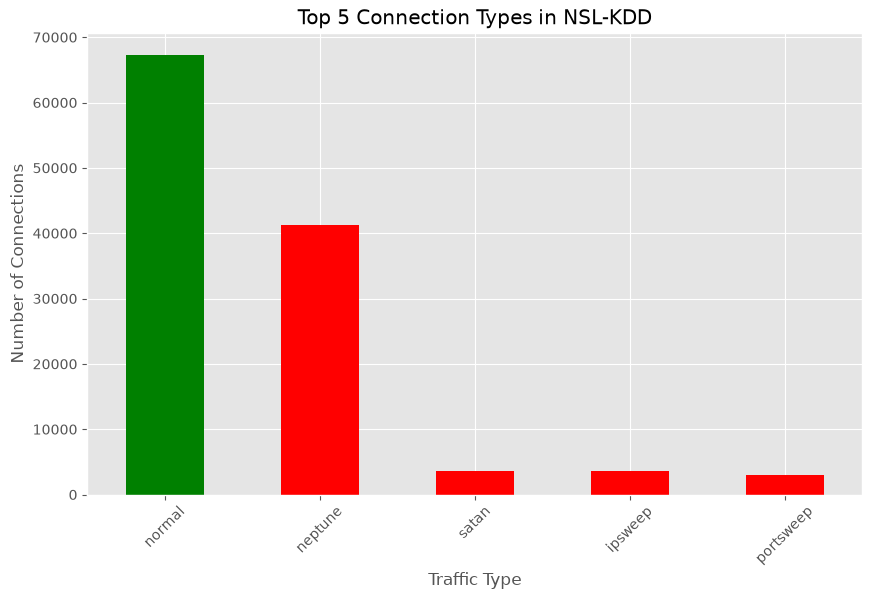

In [6]:
# Take only the top 5 labels for a cleaner graph
top_5_labels = label_counts.head(5)

# Create a bar chart. We will color 'normal' green, and all attacks red.
colors = ['green' if label == 'normal' else 'red' for label in top_5_labels.index]

plt.figure(figsize=(10, 6))
top_5_labels.plot(kind='bar', color=colors)

# Add titles and labels to make the chart professional
plt.title("Top 5 Connection Types in NSL-KDD")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Connections")
plt.xticks(rotation=45) # Tilt the text so it's easier to read

# Show the chart
plt.show()